<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>

<h1 align="center"><font size="5">King County House Price Analysis & Prediction</font></h1>


## **Project Overview**

This project explores residential property sales in King County, Washington,
with the goal of understanding which property characteristics are associated
with house prices and developing regression models for price prediction.

The analysis was completed as an applied project within IBM's
Data Analysis with Python coursework. I reorganized and documented the
analysis for my portfolio to highlight the complete analytical workflow,
model development, evaluation, and key insights.


## **About the Dataset**

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015. It was taken from [here](https://www.kaggle.com/harlfoxem/housesalesprediction?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-wwwcourseraorg-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01). It was also slightly modified for the purposes of this course. 


| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Has been viewed                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area |
| sqft_lot15    | LotSize area in 2015(implies-- some renovations)                                                            |


## **Objectives**

- Inspect and understand the housing dataset
- Clean and prepare the data for analysis
- Explore relationships between property characteristics and price
- Identify variables strongly associated with house prices
- Develop regression models for price prediction
- Evaluate model performance using R²
- Test model performance on unseen data
- Compare different modeling approaches

## **Tools & Libraries**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## **1. Data Loading & Initial Inspection**

The first step is to load the dataset and inspect its structure before performing any transformations or analysis.

In [8]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [ ]:
#!=pip install -U scikit-learn

In [9]:
import piplite
await piplite.install('seaborn')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

Downloading the dataset:


In [10]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

In [11]:
filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'

In [12]:
await download(filepath, "housing.csv")
file_name="housing.csv"

Load the csv:


In [13]:
df = pd.read_csv(file_name)

In [ ]:
#filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
#df = pd.read_csv(filepath)

In [14]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Initial Dataset Review

The dataset contains information about residential property sales along with
characteristics such as bedrooms, bathrooms, living area, floors, waterfront
status, condition, grade, location, and sale price.

The target variable for the predictive analysis is <code>price</code>.

#### Dataset Structure and Summary Statistics

In [ ]:
print(df.dtypes)

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


We use the method describe to obtain a statistical summary of the dataframe.


In [16]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## **2. Data Wrangling**


Before performing exploratory analysis, the dataset is checked for unnecessary
columns, missing values, and data-quality issues that could affect subsequent
analysis and modeling.

#### Removing Unnecessary Columns

The <code>id</code> and <code>Unnamed: 0</code> columns are removed because they act as identifiers or indexing information rather than meaningful property characteristics for the analysis.

In [17]:
df.drop(columns=["id", "Unnamed: 0"], axis=1, inplace=True)
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#### Handling Missing Values

The initial inspection identified a small number of missing observations in
the <code>bedrooms</code> and <code>bathrooms</code> columns. Because the number of missing values is small relative to the overall dataset, mean is used here to retain these observations for the subsequent analysis.

In [ ]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())


number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


In [20]:
mean = df['bedrooms'].mean()
df['bedrooms'] = df['bedrooms'].replace(np.nan, mean)

In [21]:
mean = df['bathrooms'].mean()
df['bathrooms'] = df['bathrooms'].replace(np.nan, mean)

In [22]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


The verification confirms that the missing values in these two variables have
been handled before continuing with exploratory analysis.

## **3. Exploratory Data Analysis**


Exploratory Data Analysis (EDA) is used to examine distributions, relationships, and patterns in the housing data before developing predictive models.

#### Distribution of Properties by Number of Floors

In [ ]:
df['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


#### House Price Distribution by Waterfront 

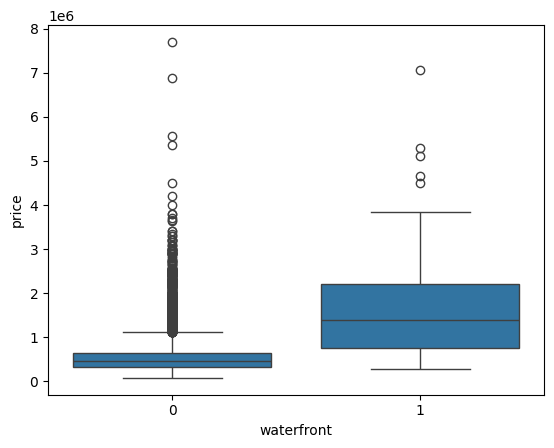

In [ ]:
sns.boxplot(x='waterfront', y='price', data=df)
plt.show()

The boxplot allows the price distributions of waterfront properties to be compared, including their medians, spread, and potential outliers.

#### Relationship Between Above-Ground Living Area and Price

(0.0, 8081250.0)

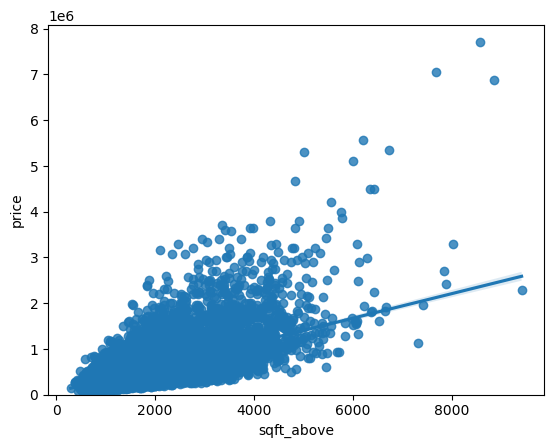

In [ ]:
sns.regplot(x="sqft_above", y="price", data=df)
plt.ylim(0,)

The regression plot is used to visually examine the direction and approximate
linearity of the relationship between above-ground living area and house price.

#### Correlation Analysis

In [27]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

##### Key Observation

Among the numerical variables examined, <code>sqft_living</code> shows one of the
strongest positive relationships with house price, with a correlation of
approximately 0.70. Other variables: <code>grade</code>, <code>sqft_above</code>, <code>sqft_living15</code>, and <code>bathrooms</code> also show notable positive relationships with price.

## **4. Model Development**


### 4.1 Simple Linear Regression
Based on the exploratory analysis, regression models are developed to examine
how effectively different combinations of property characteristics can represent variation in house prices.

In [28]:
X = df[['long']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.00046769430149007363

<code>sqft_living</code> is used as the predictor because the exploratory analysis showed a strong positive relationship between total living area and house price.

In [ ]:
#Enter Your Code, Execute and take the Screenshot
X = df[['sqft_living']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
print("R^2 score:", lm.score(X, Y))

R^2 score: 0.4928532179037931


##### Model Result

**R² ≈ 0.493**

Using <code>sqft_living</code> as the single predictor, the fitted model explains
approximately 49.3% of the variation in house prices within the data used
to fit and evaluate this model.

### 4.2 Multiple Linear Regression
House prices are influenced by more than living area alone. A multiple linear
regression model is therefore developed using several property characteristics
to examine whether incorporating additional information improves the model's
ability to represent price variation.

In [ ]:
features =["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]     

In [ ]:
X = df[features]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
print("R^2 score:", lm.score(X, Y))

R^2 score: 0.6576890354915759


##### Model Result

**R² ≈ 0.658**

The multiple linear regression model produces a higher fitted R² than the
single-feature model, indicating that the additional property characteristics
capture more of the variation in house prices within the fitted data.

### 4.3 Polynomial Regression Pipeline

A scikit-learn Pipeline is used to combine preprocessing and model development
into a consistent workflow.

The pipeline applies:
1. Feature scaling with `StandardScaler`
2. Polynomial feature transformation
3. Linear regression

In [ ]:
Input=[('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

In [ ]:
pipe = Pipeline(Input)
pipe.fit(df[features], df['price'])
print("R^2 score:", pipe.score(df[features], df['price']))

R^2 score: 0.7512051345272872


##### Model Result

**R² ≈ 0.751**

The polynomial pipeline produces a higher fitted R² than the previous linear
models, suggesting that transformed feature relationships can represent
additional structure in the data.

## **5. Model Evaluation and Refinement**


Model performance on the data used for training does not necessarily indicate
how well a model will perform on new observations. The dataset is therefore divided into training and testing subsets so that model generalization can be evaluated using unseen data.

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
print("done")

done


##### Train/Test Split

The data is divided into 85% training data and 15% testing data. The training set is used to fit the models, while the test set is reserved for evaluating how well the trained models generalize to unseen observations.

In [ ]:
features =["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]    
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


### 5.1 Ridge Regression

Ridge regression introduces regularization to constrain model coefficients,
which can help reduce sensitivity to complex or correlated feature
relationships.


In [42]:
from sklearn.linear_model import Ridge

In [43]:
#Enter Your Code, Execute and take the Screenshot
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
print("R^2 score(Test data):", RidgeModel.score(x_test, y_test))

R^2 score(Test data): 0.647875916393907


### 5.2 Polynomial Features + Ridge Regression

To capture potential non-linear relationships while retaining regularization,
second-degree polynomial features are generated and used with Ridge regression.


In [46]:
#Enter Your Code, Execute and take the Screenshot
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

RidgeModel_2 = Ridge(alpha=0.1)
RidgeModel_2.fit(x_train_pr, y_train)

print("R^2 score(Polynomial Test data):", RidgeModel_2.score(x_test_pr, y_test))

R^2 score(Polynomial Test data): 0.7002744263583341


##### Test Result

**Test R² ≈ 0.700**

Adding second-degree polynomial features increased the held-out test R² from
approximately 0.648 for the standard Ridge model to approximately 0.700. This suggests that the transformed features capture additional relationships
that are useful for prediction on the test data.

## **6. Model Comparison**

| Model | Evaluation Data | R² |
|---|---|---:|
| Simple Linear Regression | Fitted data | 0.493 |
| Multiple Linear Regression | Fitted data | 0.658 |
| Polynomial Regression Pipeline | Fitted data | 0.751 |
| Ridge Regression | Test data | 0.648 |
| Polynomial Features + Ridge | Test data | 0.700 |

##### Model Evaluation Conclusion

The results show a clear improvement as the models became more comprehensive. Simple Linear Regression achieved an R² of 0.493, while using multiple features increased it to 0.658. The Polynomial Regression Pipeline further improved the fitted R² to 0.751, showing the value of capturing more complex feature relationships.

On unseen test data, Ridge Regression achieved an R² of 0.648, while Polynomial Features + Ridge Regression improved it to 0.700, indicating better generalization with polynomial features.

 Overall, the results demonstrate the importance of multiple features, feature transformation, regularization, and evaluation on unseen data when developing predictive models.

<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Michelle Carey</a>, <a href="https://www.linkedin.com/in/jiahui-mavis-zhou-a4537814a?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Mavis Zhou</a>



## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
<!--## Change Log

| Date (YYYY-MM-DD) | Version | Changed By      | Change Description                           |
| ----------------- | ------- | --------------- | -------------------------------------------- |
| 2020-12-01        | 2.2     | Aije Egwaikhide | Coverted Data describtion from text to table |
| 2020-10-06        | 2.1     | Lakshmi Holla   | Changed markdown instruction of Question1    |
| 2020-08-27        | 2.0     | Malika Singla   | Added lab to GitLab                          |
| 2022-06-13        | 2.3     | Svitlana Kramar | Updated Notebook sharing instructions        |
| <hr>              |         |                 |                                              |


--!>
<p>
